In [8]:
# Instalar dependencias
%pip install -U google-genai Pillow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
# Importando librerias
import os
import requests
from pathlib import Path
from PIL import Image
import io
from IPython.display import display
from dotenv import load_dotenv
import json

# Configuración de la API
load_dotenv()
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
BASE_DIR = Path.cwd()

## Paso 1: Generación

Solicita al usuario un "Personaje" y un "Escenario". Envía un prompt a Gemini para que genere una leyenda breve y una imagen cinematográfica.

In [10]:
# Funcion para generar contenido con OpenRouter y un motor de imágenes gratuito

prompt_base = "Escribe una leyenda breve y cinematográfica sobre {personaje} en {escenario}."

def generar_con_openrouter(personaje, escenario):
    # Generando texto de leyenda con OpenRouter    
    print("Generando leyenda con OpenRouter...")
    response = requests.post(
        url="https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        },
        json={
            "model": "google/gemini-2.0-flash-001", # Pertenece a la capa gratuita de OpenRouter
            "messages": [
                {"role": "user", "content": prompt_base}
            ]
        }
    )
    
    # Extrayendo el texto generado
    texto = response.json()['choices'][0]['message']['content'].strip()

    # Generando imagen con un servicio gratuito (Pollinations)
    print("Generando imagen...")
    prompt_img = f"cinematic digital art, {personaje}, {escenario}, high detail, 8k".replace(" ", "%20")
    url_img = f"https://image.pollinations.ai/prompt/{prompt_img}"
    
    img_res = requests.get(url_img)
    imagen = Image.open(io.BytesIO(img_res.content))
    
    # Guardar la imagen localmente
    ruta = BASE_DIR / "portada_openrouter.png"
    imagen.save(ruta)
    
    return texto, imagen, ruta

## Paso 2: Visualización

Muestra el texto por consola y abre la imagen generada.

Generando leyenda con OpenRouter...
Generando imagen...

LEYENDA:
Por favor, dame la información que falta. ¿Quién es el personaje y cuál es el escenario? Necesito saber a quien se refiere con "{personaje}" y "{escenario}" para poder escribir la leyenda.

Por ejemplo:

* **{personaje}:** Un viejo vaquero llamado Desierto
* **{escenario}:** Un cementerio olvidado en el corazón del desierto de Mojave

Con esa información, podré crear una leyenda breve y cinematográfica.



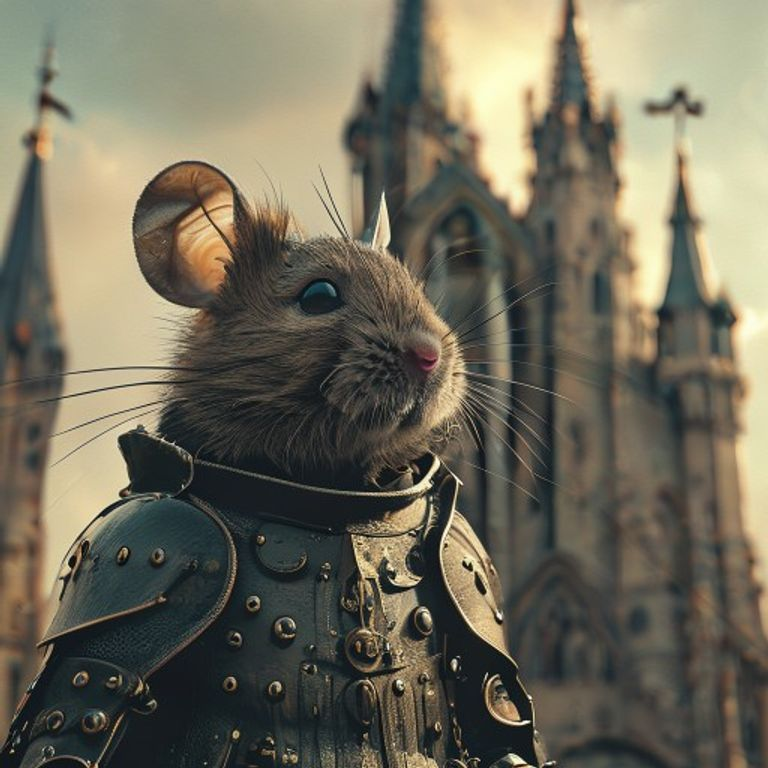

In [ ]:
# Solicitando datos al usuario y generando contenido
personaje = "Un pequeño ratón caballero con armadura de aguja"
escenario = "Una catedral gótica con luz de vitrales"
# personaje = input("Describe el personaje (ej: 'Un pequeño ratón caballero con armadura de aguja'): ")
# escenario = input("Describe el escenario (ej: 'Una catedral gótica con luz de vitrales'): ")

# Ejecutando la función y mostrando los resultados
try:
    texto, img, ruta = generar_con_openrouter(personaje, escenario)
    print(f"\nLEYENDA:\n{texto}\n")
    display(img)
except Exception as e:
    print(f"Error: {e}")

## Paso 3: Feedback

Pregunta al usuario: "¿Qué cambios te gustaría hacer?".

In [12]:
# --- PASO 3: FEEDBACK DEL USUARIO ---
feedback = input("¿Qué cambios te gustaría hacer a la portada? (ej: 'hazlo más oscuro', 'añade nieve'): ")

## Paso 4: Iteración

Realiza una segunda llamada al modelo enviando: Prompt Original + Feedback del usuario. Guarda y muestra la nueva imagen como portada_final.png.

In [13]:
# Construimos el historial para que el modelo tenga contexto (Iteración)

mensajes_iteracion = [
    {
        "role": "user", 
        "content": prompt_base # El prompt original que usaste en el Paso 1
    },
    {
        "role": "assistant", 
        "content": "Aquí tienes la descripción e imagen inicial." # Simulación de la respuesta anterior
    },
    {
        "role": "user", 
        "content": f"Basado en la imagen anterior, aplica este cambio: {feedback}. Genera una nueva descripción y una nueva imagen."
    }
]

# Llamada a OpenRouter (igual que hiciste en la primera celda)
response_iteracion = requests.post(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        },
        json={
            "model": "google/gemini-2.0-flash-001", # Pertenece a la capa gratuita de OpenRouter
            "messages": [
                {"role": "user", "content": prompt_base}
            ]
        }
    )

# Extrayendo el nuevo texto generado
response_iter = response_iteracion.json()
nuevo_contenido = response_iter['choices'][0]['message']['content'].strip()

# Generar la imagen final con el nuevo prompt (usando Pollinations como en tu paso 1)
# Usamos el feedback y los datos originales para construir la nueva URL
prompt_final_url = f"cinematic digital art, {personaje}, {escenario}, {feedback}, high detail, 8k".replace(" ", "%20")
url_img_final = f"https://image.pollinations.ai/prompt/{prompt_final_url}"

img_res_final = requests.get(url_img_final)

En este último apartado, volvemos a llamar al modelo, y creamos la imagen modificada. En la cual se muestra la imagen y su nueva descripción


--- LEYENDA FINAL ---
Por favor, dime a quién debemos interpretar como el personaje y cuál debe ser el escenario. Por ejemplo:

*   **Personaje:** Una joven aprendiz de hechicera
*   **Escenario:** Un cementerio bañado por la luna

Una vez que me des esos detalles, te escribiré una leyenda cinematográfica.


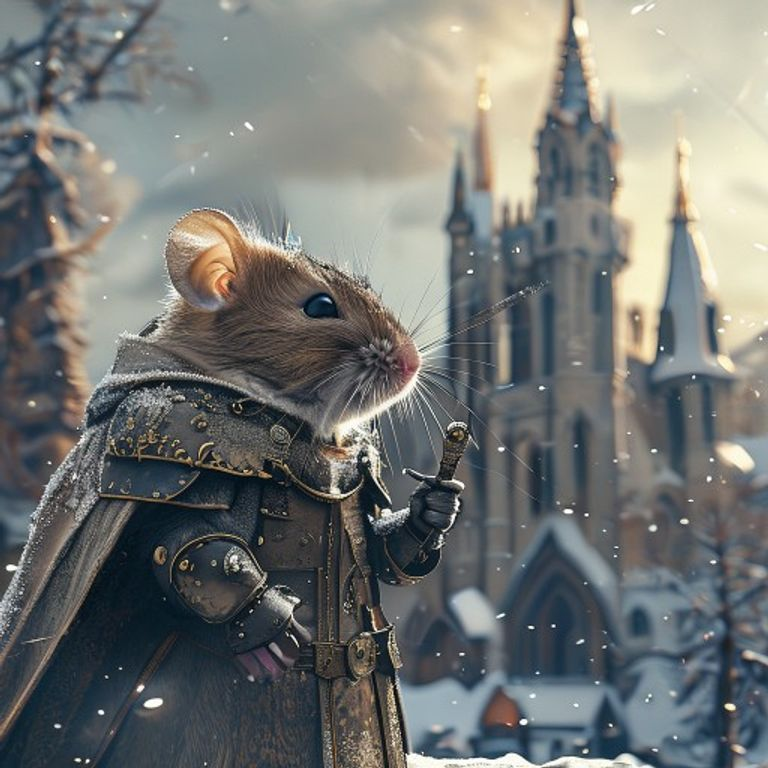


Imagen guardada como: /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Tema 4/Actividad_4.6/portada_final.png


In [ ]:
# --- PROCESAMIENTO Y GUARDADO FINAL ---
# Aquí debes extraer la imagen de la respuesta de la misma forma que hiciste antes
if img_res_final.status_code == 200 and 'image' in img_res_final.headers.get('Content-Type', ''):
    try:
        # Convertimos los bytes en imagen
        image_bytes_final = img_res_final.content
        imagen_final = Image.open(io.BytesIO(image_bytes_final))

        # Guardado de la imagen final modificada
        ruta_final = BASE_DIR / "portada_final.png"
        imagen_final.save(ruta_final)

        # Visualizacion y resumen final
        print("\n--- LEYENDA FINAL ---")
        print(nuevo_contenido if 'nuevo_contenido' in locals() else "Nueva descripción generada.")
        
        display(imagen_final)
        print(f"\nImagen guardada como: {ruta_final}")

    except Exception as e:
        print(f"Error al procesar los bytes de la imagen: {e}")
else:
    print("Error: Pollinations no devolvió una imagen válida.")
    print("Contenido recibido:", img_res_final.text[:100])